# Use 50000R
 - For n_tets = 3, n_cells ~ 230,000
 - lowest overall rank for contact size
 - Get good meshes for n_tets = [1, 2, 3]
### Story so far
 - StMmLt study showed that taper_size needs to be ≤0.25 to prevent significant missing cells around the edge
 - And each preferred different p_h which was expected
    - use p_h = 8.5 as this has logic for being reasonable for everyone
 - optCombos showed best: 
 - ODT - tweak per subject to try and keep anatomy the same
 - perturb ≥ 20
 - exude = 0

In [70]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [169]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/meshInd') # path to parent of output_root in set_parameters
study_prefix = 'study1' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/meshInd-{study_prefix}') # path dir to save outputs in
suffixes = ['a', 'b', 'c', 'd', 'e', 'f'] # individual study identifier (end of dir name of output_root in set_parameters)

In [170]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
extra_params = [
    'cgal_params.sizing_field.taper_size',
    'cgal_params.sizing_field.n_tets',
    'cgal_params.optimisation.odt',
    'cgal_params.odt.max_iteration_number',
    'cgal_params.odt.freeze_bound',
    'cgal_params.optimisation.lloyd',
    'cgal_params.lloyd.max_iteration_number',
    'cgal_params.lloyd.freeze_bound'
    ]
get_params3d(root_dir, study_prefix, suffixes, extra_params).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [171]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [172]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

63


Highest element count:
	50000R - 217361


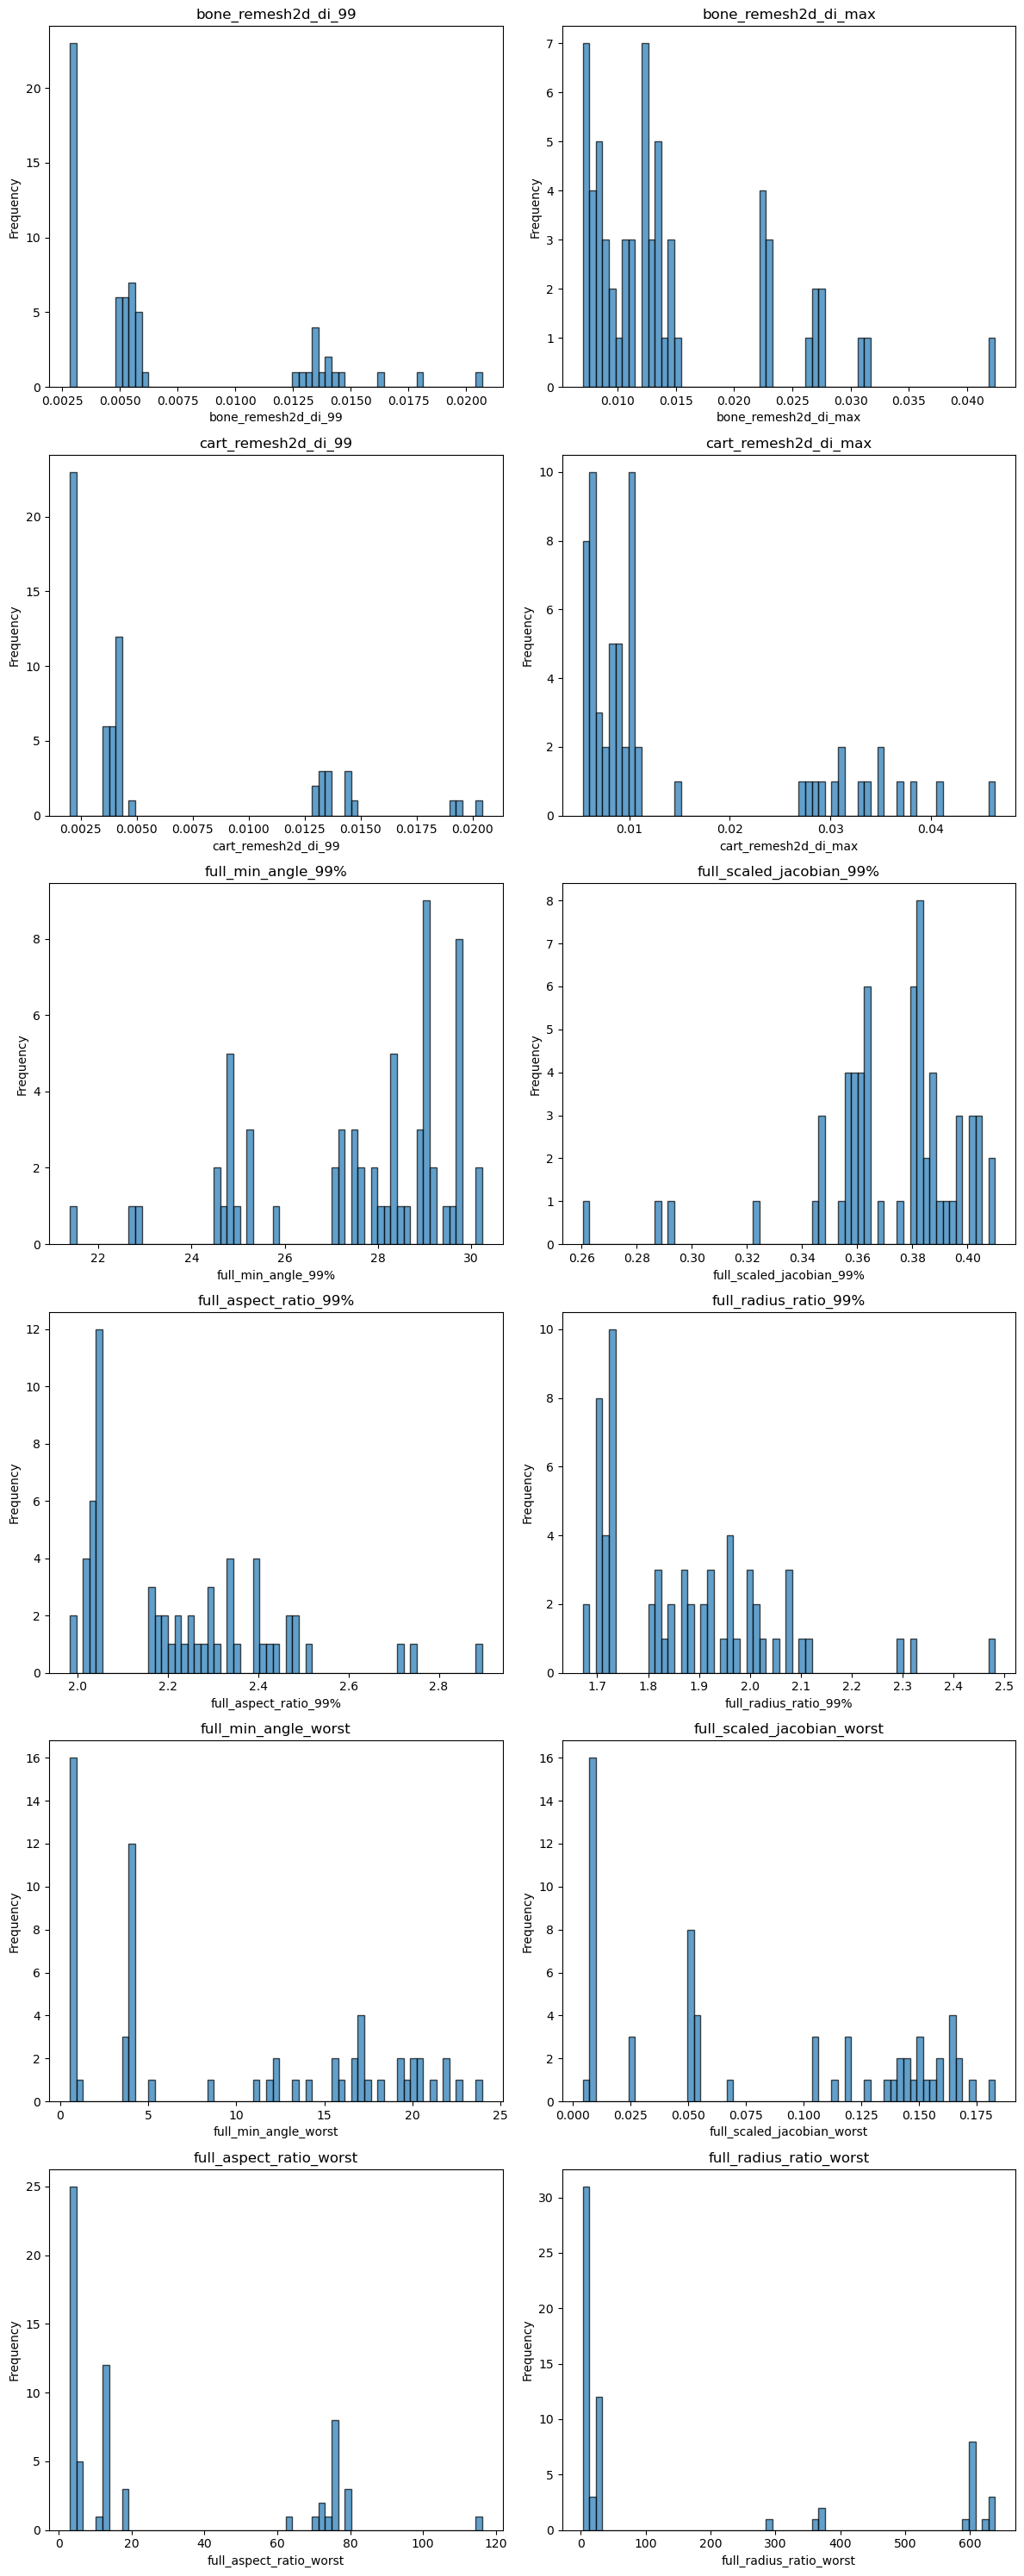

In [173]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 1)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [174]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

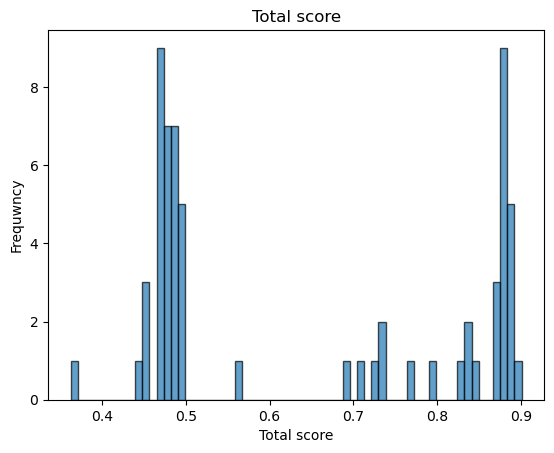

In [175]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/1), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    #ax.legend()

In [176]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank.head(10)

,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.n_tets,cgal_params.optimisation.odt,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,cgal_params.optimisation.lloyd,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,mean_rank,median_rank,best_rank,n_runs
53,0.25,3,True,10,0.0100,False,0,0.0010,1.0,1.0,1.0,1
51,0.25,3,True,10,0.0005,False,0,0.0010,2.0,2.0,2.0,1
57,0.25,3,True,20,0.0100,False,0,0.0010,3.0,3.0,3.0,1
61,0.25,3,True,30,0.0100,False,0,0.0010,4.0,4.0,4.0,1
55,0.25,3,True,20,0.0005,False,0,0.0010,5.0,5.0,5.0,1
50,0.25,3,True,10,0.0001,False,0,0.0010,6.0,6.0,6.0,1
54,0.25,3,True,20,0.0001,False,0,0.0010,7.0,7.0,7.0,1
24,0.25,2,False,10,0.0100,True,30,0.0005,8.0,8.0,8.0,1
58,0.25,3,True,30,0.0001,False,0,0.0010,9.0,9.0,9.0,1
60,0.25,3,True,30,0.0010,False,0,0.0010,10.0,10.0,10.0,1


In [177]:
best_per_tet = df_score_param.groupby('cgal_params.sizing_field.n_tets').first()
best_per_tet

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,total,rank_within_case,cgal_params.sizing_field.taper_size,cgal_params.optimisation.odt,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,cgal_params.optimisation.lloyd,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound
cgal_params.sizing_field.n_tets,,,,,,,,,,,,,,,,,,,,
1,50000R,tpm,0-0-6-0e,0.858031,0.838402,1.0,1.0,1.0,0.093705,0.967103,1.0,0.844655,19.0,0.25,False,10,0.01,True,20,0.0005
2,50000R,tpm,0-0-10-0d,0.953863,1.000000,1.0,1.0,1.0,0.113402,1.000000,1.0,0.883408,8.0,0.25,False,10,0.01,True,30,0.0005
3,50000R,tpm,0-0-12-0b,0.989430,0.917121,1.0,1.0,1.0,0.301906,1.000000,1.0,0.901057,1.0,0.25,True,10,0.01,False,0,0.0010


In [178]:
best_per_tet.merge(df_score_qual[(df_score_qual['sub']==sub)])[['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_y' in x]]

,sub,bone,run_id,full_min_angle_worst_y,full_min_angle_99%_y,full_radius_ratio_worst_y,full_radius_ratio_99%_y,full_aspect_ratio_worst_y,full_aspect_ratio_99%_y,full_scaled_jacobian_worst_y,full_scaled_jacobian_99%_y
0,50000R,tpm,0-0-6-0e,18.303712,25.740923,3.854639,1.955659,4.065794,2.334249,0.144185,0.367680
1,50000R,tpm,0-0-10-0d,17.444867,28.615890,3.793613,1.801416,3.865188,2.159890,0.150544,0.403644
2,50000R,tpm,0-0-12-0b,21.946640,29.682914,3.055249,1.713387,3.114523,2.033452,0.183184,0.383424


## Final meshes

In [180]:
path1 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1e/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-6.vtu'
path2 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1d/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-10.vtu'
path3 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1b/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-12.vtu'
T1 = pv.read(path1)
T2 = pv.read(path2)
T3 = pv.read(path3)
print(T1.n_cells, T2.n_cells, T3.n_cells)
T1.plot()
T2.plot()
T3.plot()

46595 114683 246929


Widget(value='<iframe src="http://localhost:51577/index.html?ui=P_0x350738a10_28&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:51577/index.html?ui=P_0x32e523ef0_29&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:51577/index.html?ui=P_0x350739700_30&reconnect=auto" class="pyvist…

# Can't use ODT if n_tets = 1
 - Results in it putting holes all over the surface
 - odt=false and taper_size=0.5, resulted in holes at the edge
 Need taper_size ≤ 0.25 to prevent edge holes

In [41]:
import subprocess

path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/holes/params/full_params-8.json

SUBJECT: 50000R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.518s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.524s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 13.058s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [42]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/meshIndependance/outputs/holes/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu'
pv.read(path).plot()

Widget(value='<iframe src="http://localhost:51577/index.html?ui=P_0x350a65790_13&reconnect=auto" class="pyvist…